# Week 08 (Module 19) - BBO capstone driver

Round 8. Partition-BO went 0-for-5 last week, and the high-x5 hunch on f8 was disproven. The one real gain was **f1's first non-zero reading in 7 weeks** (-0.0053 near (0.41, 0.47)).

This week's module was LLMs, so I added a **language-model reasoning layer** for the functions where my data-driven model is broken - reasoning from each function's plain-text brief plus its result history, then validating the proposed point against the submission format.

**Plan (hybrid: LLM-reasoned, tight-refine, and data-driven):**
- **f1 -> LLM-reasoned probe** (0.46, 0.49): step ~0.06 from the first non-zero toward box centre to test whether the faint signal strengthens and find a gradient. GP is broken here (R^2 = -0.57), so reasoning from the brief earns its place.
- **f2 -> AEI conservative** (weak model, near-incumbent).
- **f3 -> EI** (partial-reliable model).
- **f4 -> tight refine**: perturb the proven W2 winner (0.54) by a whisker. After 3 confident misses above 0.5, that winner is the practical ceiling - bank near it.
- **f5 -> space_fill** (keep exploring cheap; (1,1,1,1)=8662 stays banked for the FINAL week).
- **f6 -> AEI conservative**.
- **f7 -> tight refine**: perturb the W2 winner (1.688). Partition proved the neighbourhood is good; the model now predicts 1.698 +/- 0.04, a possible small gain.
- **f8 -> MES**: back to the reliable converged point; high-x5 is dead.


In [1]:
%matplotlib inline
import os, sys, warnings
warnings.filterwarnings("ignore")
_root = os.getcwd()
while not os.path.exists(os.path.join(_root, "bo.py")) and os.path.dirname(_root) != _root:
    _root = os.path.dirname(_root)
os.chdir(_root); sys.path.insert(0, _root)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bo

WEEK = 8
SEED = 0
rng = np.random.default_rng(SEED)
OUTDIR = f"outputs/week{WEEK:02d}"; os.makedirs(OUTDIR, exist_ok=True)

results = {}

# f1: LLM-reasoned probe near the first non-zero reading, stepped toward centre.
f1_x = np.array([0.460000, 0.490000])
results[1] = dict(x=f1_x, u=f1_x, submission=bo.format_submission(f1_x),
                  acq="llm_probe", mean=float('nan'), std=float('nan'),
                  incumbent_y=0.0, n_data=len(bo.load(1)[1]))

# f4, f7: tight refine - small perturbation of the proven incumbent.
def tight_refine(fid, scale=0.02):
    X, y, d = bo.load(fid); b = bo.bounds(fid, d)
    u_best = bo.to_unit(X[int(np.argmax(y))].reshape(1,-1), b).reshape(-1)
    u_new = np.clip(u_best + rng.normal(0, scale, size=d), 0.0, 1.0)
    x_new = bo.from_unit(u_new, b); m = bo.fit(fid)
    mean, std = m.predict(u_new.reshape(1,-1))
    return dict(x=x_new, u=u_new, submission=bo.format_submission(x_new), acq="tight_refine",
               mean=float(mean[0]), std=float(std[0]), incumbent_y=float(y.max()),
               n_data=len(y), model=m)
results[4] = tight_refine(4)
results[7] = tight_refine(7)

# Data-driven picks.
GP_PLAN = {2: dict(acq="aei", xi=0.10), 3: dict(acq="ei", xi=0.01),
           5: dict(acq="space_fill"), 6: dict(acq="aei", xi=0.10), 8: dict(acq="mes")}
for fid, plan in GP_PLAN.items():
    results[fid] = bo.run_function(fid, seed=SEED, **plan)

for fid in bo.FUNC_IDS:
    bo.validate_submission(results[fid]["submission"], len(results[fid]["x"]))

pd.DataFrame([dict(func=f"f{fid}", source=results[fid]["acq"],
                   incumbent=round(results[fid]["incumbent_y"], 4),
                   submission=results[fid]["submission"]) for fid in bo.FUNC_IDS])


,func,source,incumbent,submission
0,f1,llm_probe,0.0000,0.460000-0.490000
1,f2,aei,0.6112,0.683947-0.025798
2,f3,ei,-0.0348,0.913105-0.000000-0.091277
3,f4,tight_refine,0.5401,0.411885-0.414684-0.365642-0.437550
4,f5,space_fill,8662.4050,0.965208-0.077388-0.960107-0.001138
5,f6,aei,-0.7048,0.479081-0.366380-0.597993-0.728146-0.000000
6,f7,tight_refine,1.6876,0.000000-0.121321-0.041032-0.171272-0.332222-0...
7,f8,mes,9.9498,0.121737-0.148860-0.117769-0.213503-0.999999-0...


## 1. Data - seed the working CSVs and review the function descriptions

In [2]:
bo.seed_csvs()          # data/f1..f8.csv from initial_data/*.npy (no-op once they exist)
bo.write_descriptions() # data/function_descriptions.csv
pd.read_csv("data/function_descriptions.csv")[["func", "dims", "n_seed", "character", "application"]]

,func,dims,n_seed,character,application
0,1,2,10,Sparse/flat (mostly ~0 except near sources); m...,Radiation/contamination source detection in a ...
1,2,2,10,Noisy + multimodal with many local peaks.,Mystery ML model returning a noisy log-likelih...
2,3,3,15,Maximise a negated cost (toward 0).,Drug discovery: combinations of three compound...
3,4,4,30,Dynamic with many local optima.,Warehouse product-placement surrogate; output ...
4,5,4,20,"Typically unimodal, a single peak.",Chemical-process yield.
5,6,5,20,Negative-by-design; maximise toward 0.,Cake recipe with five ingredients; combined ne...
6,7,6,30,Black-box; literature priors can inform the se...,"ML hyperparameter tuning (lr, reg, #layers...)..."
7,8,8,40,High-dimensional; global optimisation hard.,"8-param ML hyperparameter tuning (lr, batch, l..."


## 2. Fit a surrogate and propose the next query for all 8 functions

In [3]:
summary = pd.DataFrame([
    dict(func=f"f{fid}", d=len(results[fid]["x"]), n_data=results[fid]["n_data"],
         incumbent_y=round(results[fid]["incumbent_y"], 4),
         pred_mean=round(results[fid]["mean"], 4) if results[fid]["mean"]==results[fid]["mean"] else None,
         pred_std=round(results[fid]["std"], 4) if results[fid]["std"]==results[fid]["std"] else None,
         acq_used=results[fid]["acq"], submission=results[fid]["submission"])
    for fid in bo.FUNC_IDS
])
summary


,func,d,n_data,incumbent_y,pred_mean,pred_std,acq_used,submission
0,f1,2,17,0.0000,NaN,NaN,llm_probe,0.460000-0.490000
1,f2,2,17,0.6112,0.5161,0.1097,aei,0.683947-0.025798
2,f3,3,22,-0.0348,-0.0477,0.0444,ei,0.913105-0.000000-0.091277
3,f4,4,37,0.5401,0.3364,0.2509,tight_refine,0.411885-0.414684-0.365642-0.437550
4,f5,4,27,8662.4050,-68.9226,1104.5400,space_fill,0.965208-0.077388-0.960107-0.001138
5,f6,5,27,-0.7048,-0.4987,0.1481,aei,0.479081-0.366380-0.597993-0.728146-0.000000
6,f7,6,37,1.6876,1.6985,0.0407,tight_refine,0.000000-0.121321-0.041032-0.171272-0.332222-0...
7,f8,8,47,9.9498,9.9499,0.0013,mes,0.121737-0.148860-0.117769-0.213503-0.999999-0...


### Acquisition values at each proposed point
All four acquisitions are computed every round so the choice can be justified in the reflection.

In [4]:
for fid in bo.FUNC_IDS:
    r = results[fid]
    if "acq_all" not in r:
        m = r.get("model") or bo.fit(fid)
        r["model"] = m
        r["acq_all"] = {k: float(v[0]) for k, v in bo.acq_values(m, np.atleast_2d(r["u"])).items()}
pd.DataFrame([
    dict(func=f"f{fid}", **{k: round(v, 4) for k, v in results[fid]["acq_all"].items()})
    for fid in bo.FUNC_IDS
])


,func,ei,ucb,pi,var
0,f1,0.0000,0.0001,0.0000,0.000000e+00
1,f2,0.0016,0.7354,0.0376,1.200000e-02
2,f3,0.0086,0.0411,0.3032,2.000000e-03
3,f4,0.0275,0.8381,0.1971,6.290000e-02
4,f5,0.0000,2140.1574,0.0000,1.220009e+06
5,f6,0.1267,-0.2025,0.7631,2.190000e-02
6,f7,0.0167,1.7799,0.5088,1.700000e-03
7,f8,0.0000,9.9524,0.0000,0.000000e+00


## 3. Visualise
2D functions get full posterior + acquisition heatmaps; higher-D functions get 1D slices
through the incumbent. Every function gets convergence + leave-one-out diagnostics.

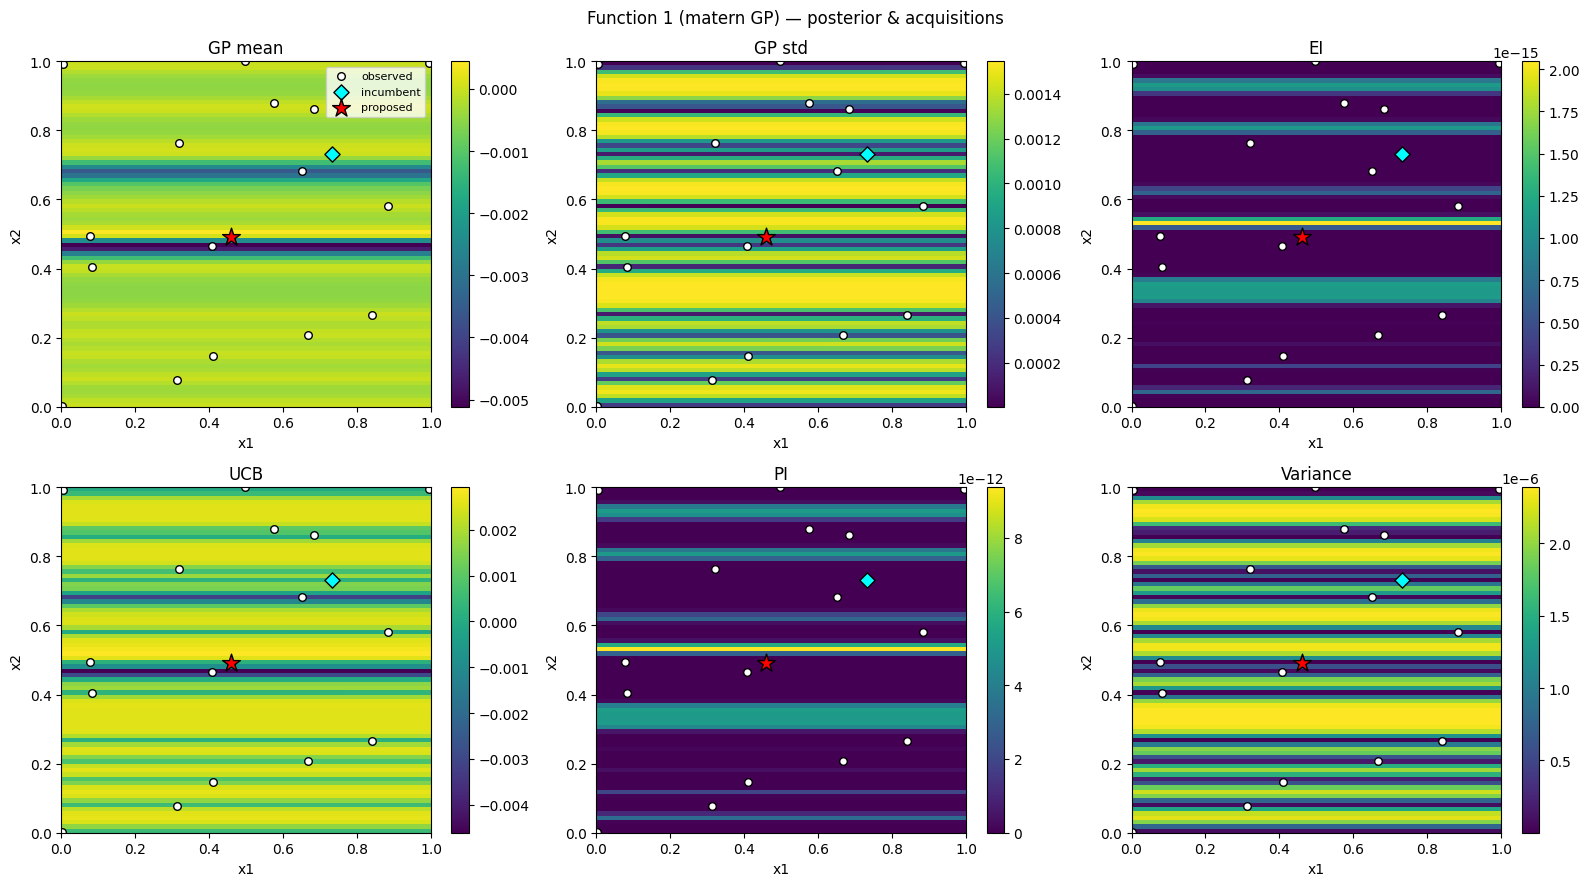

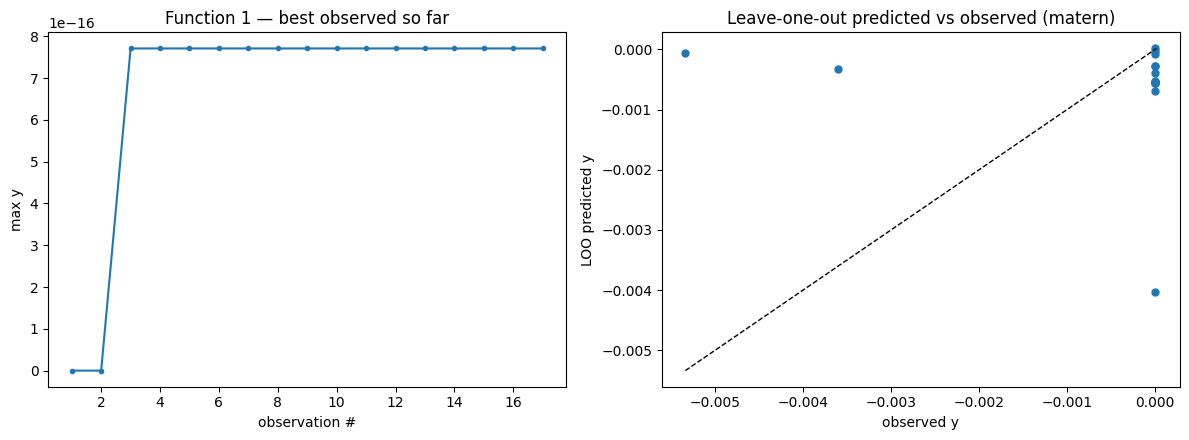

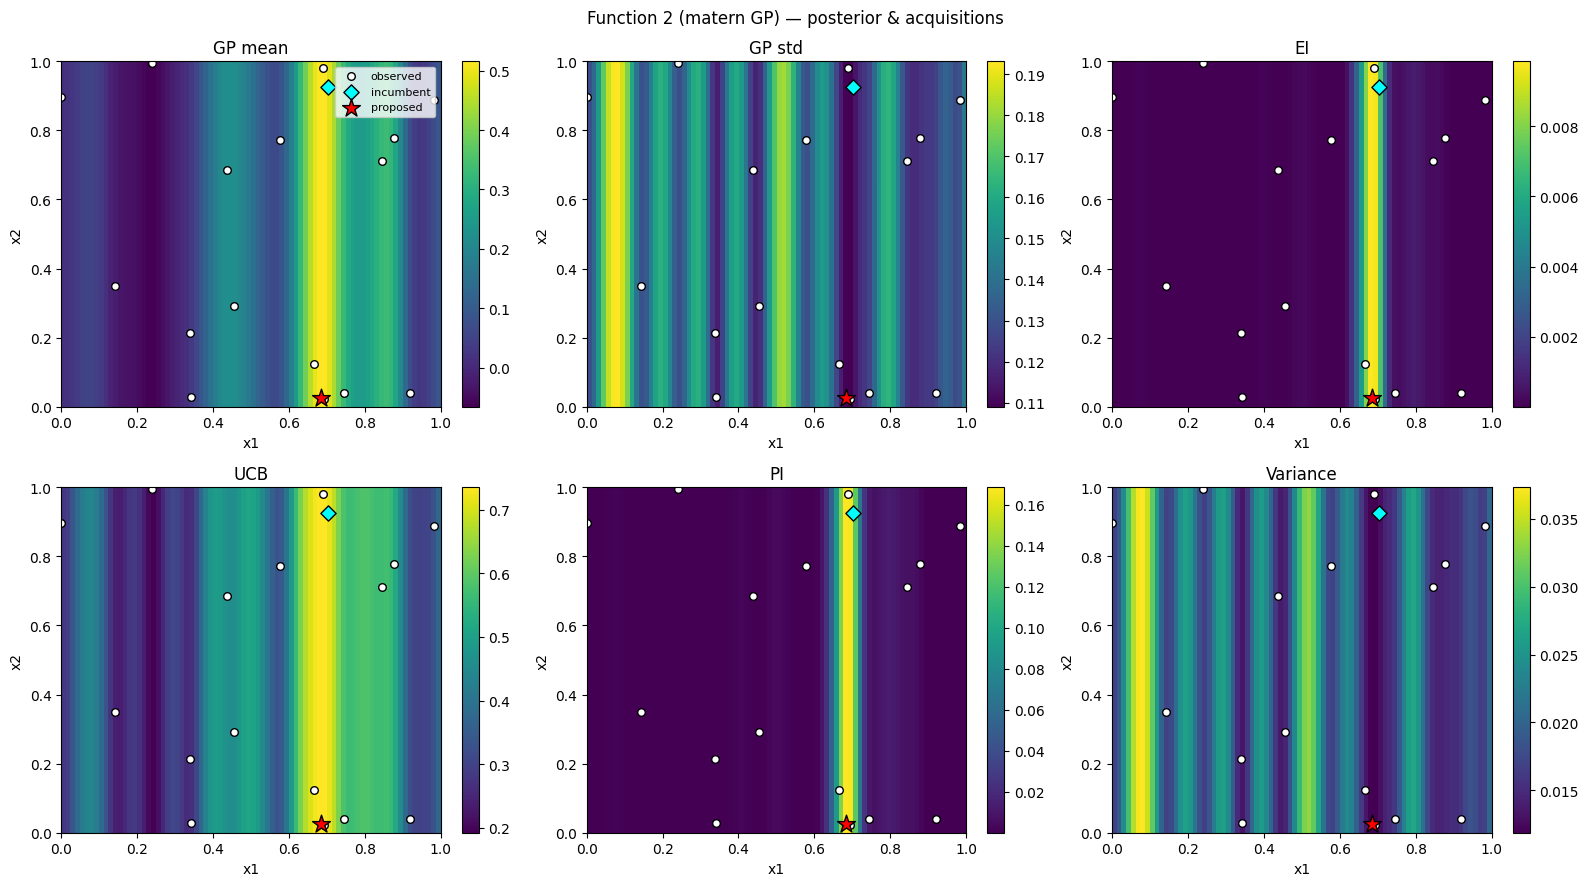

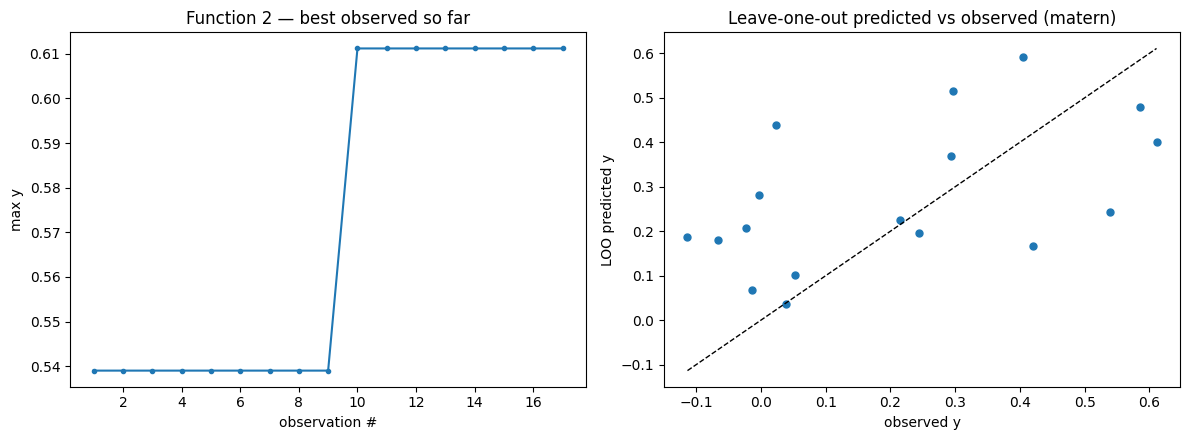

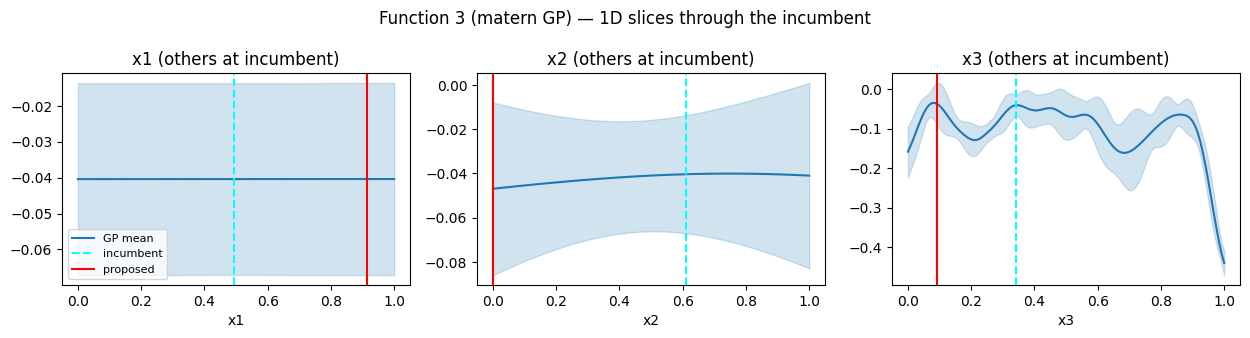

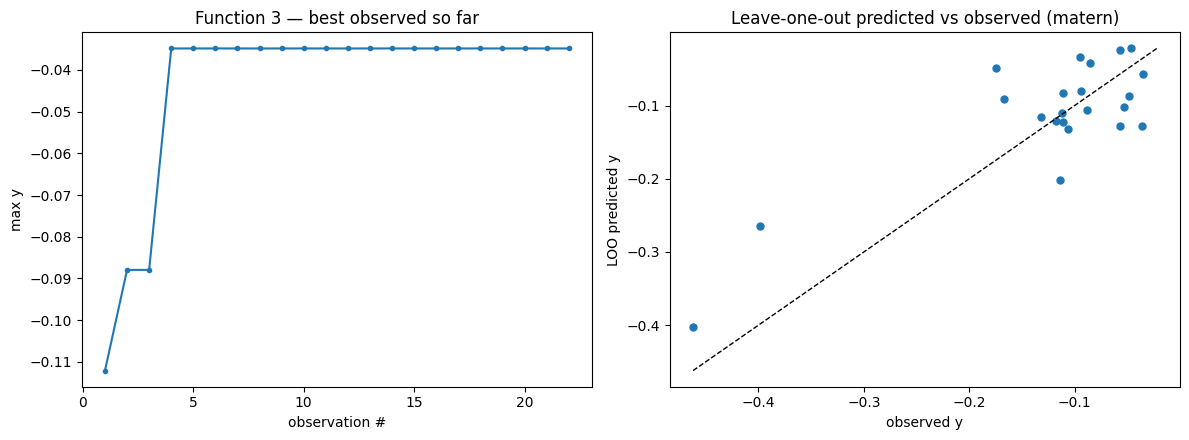

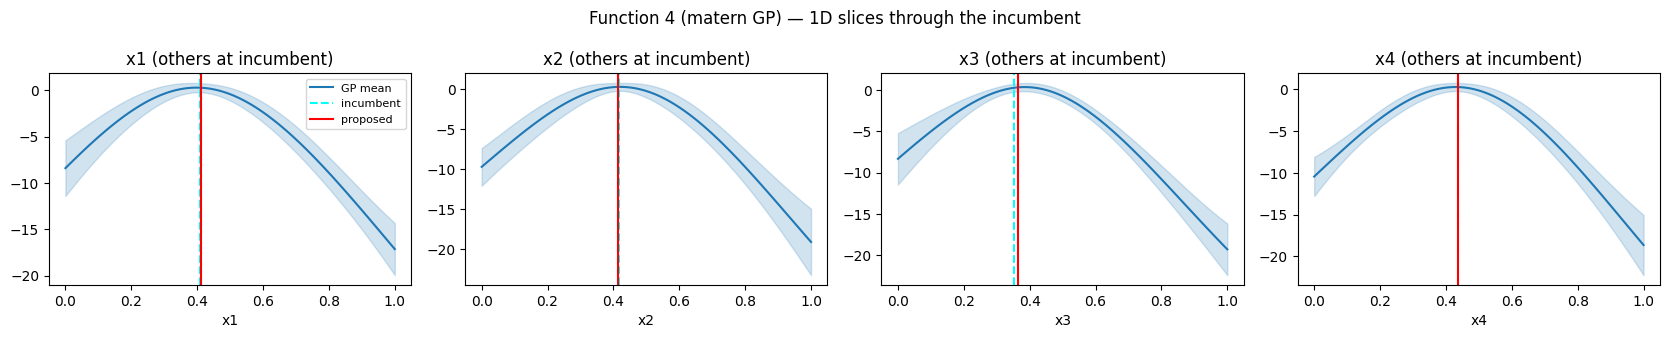

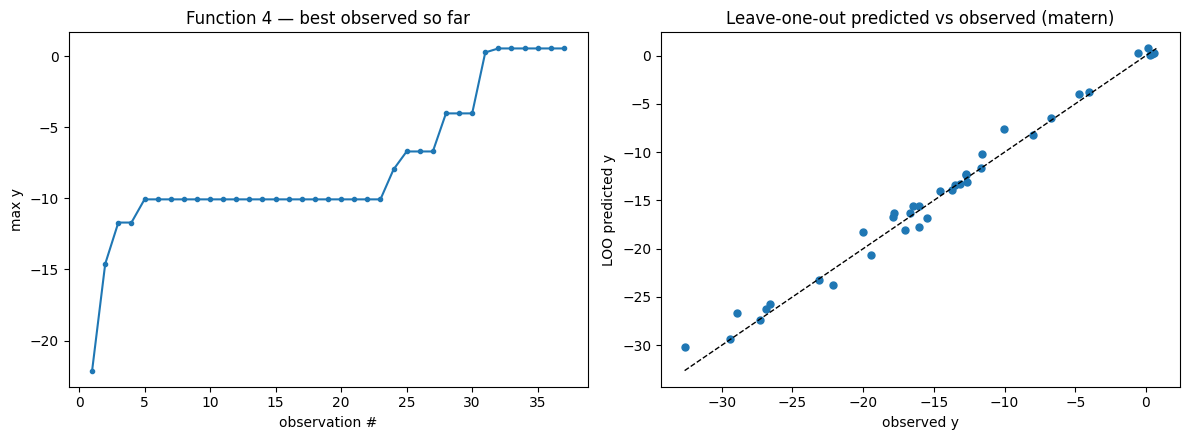

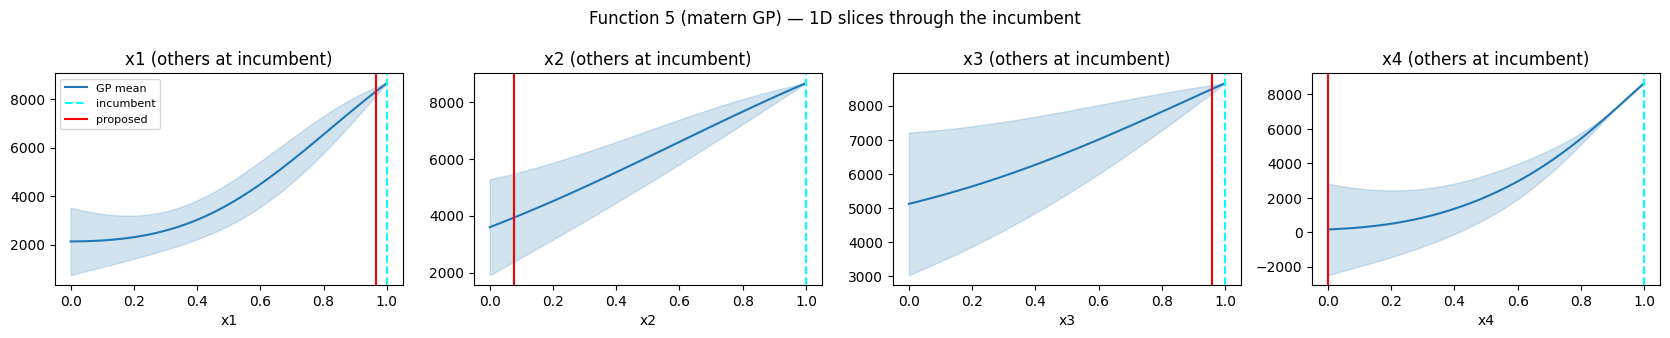

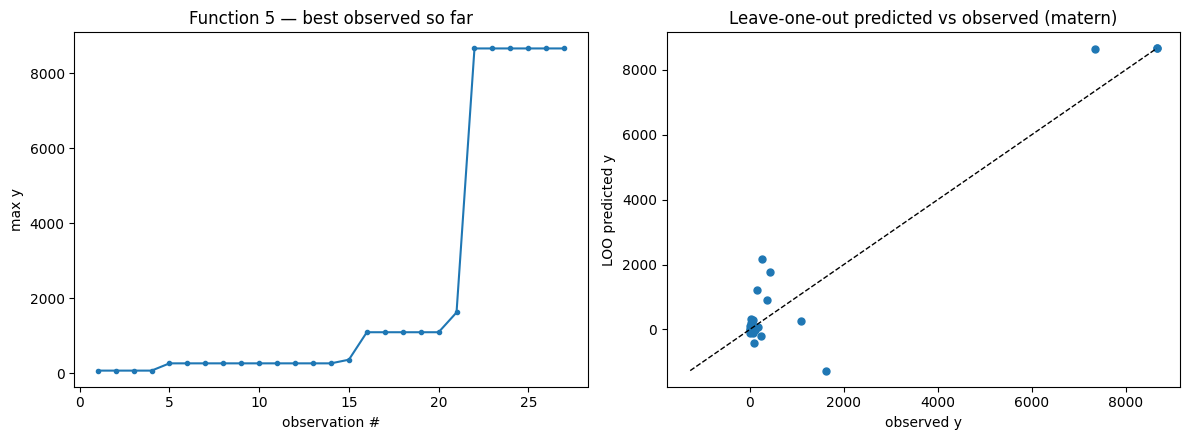

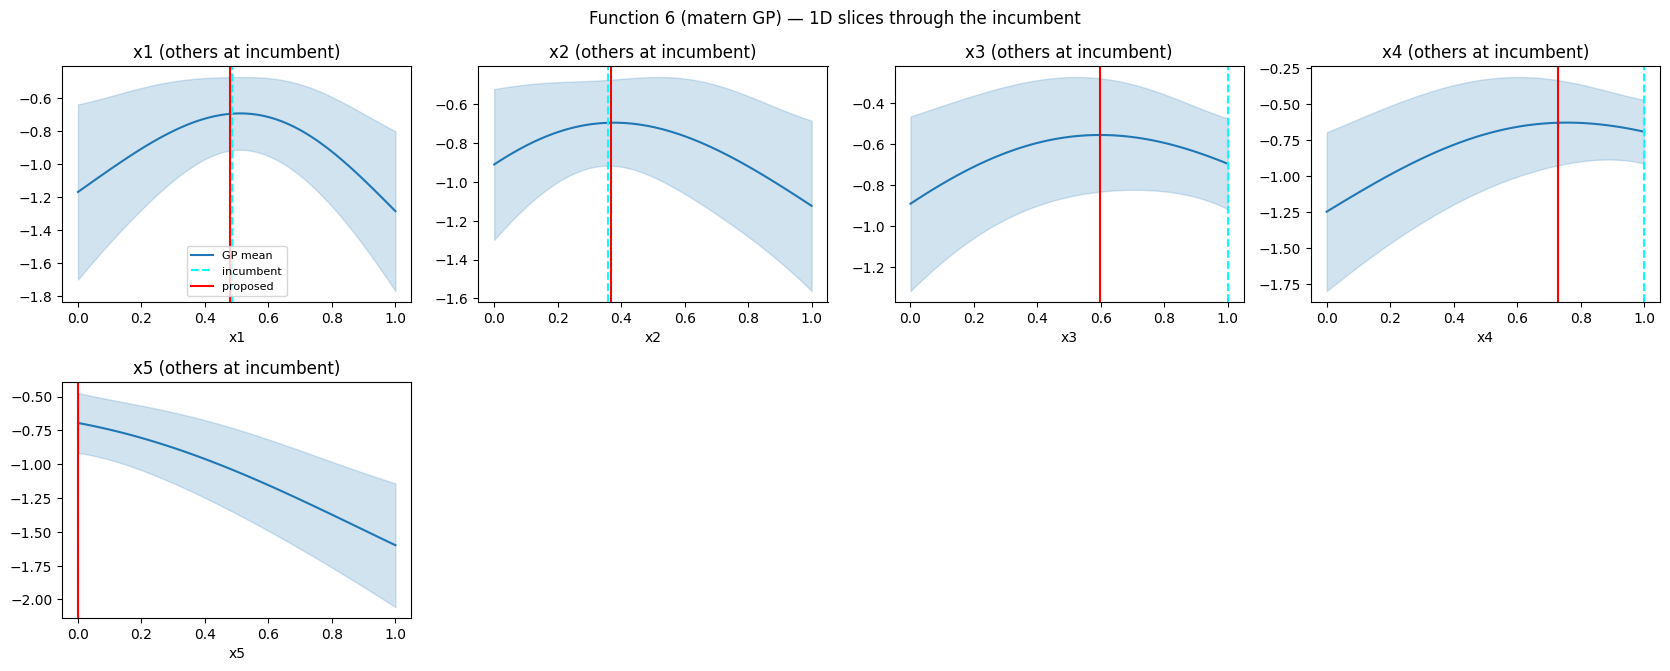

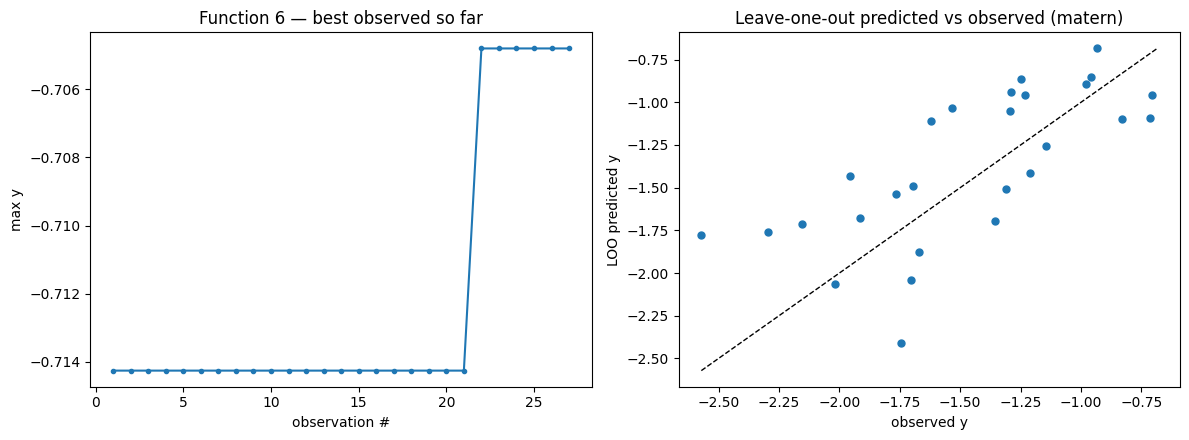

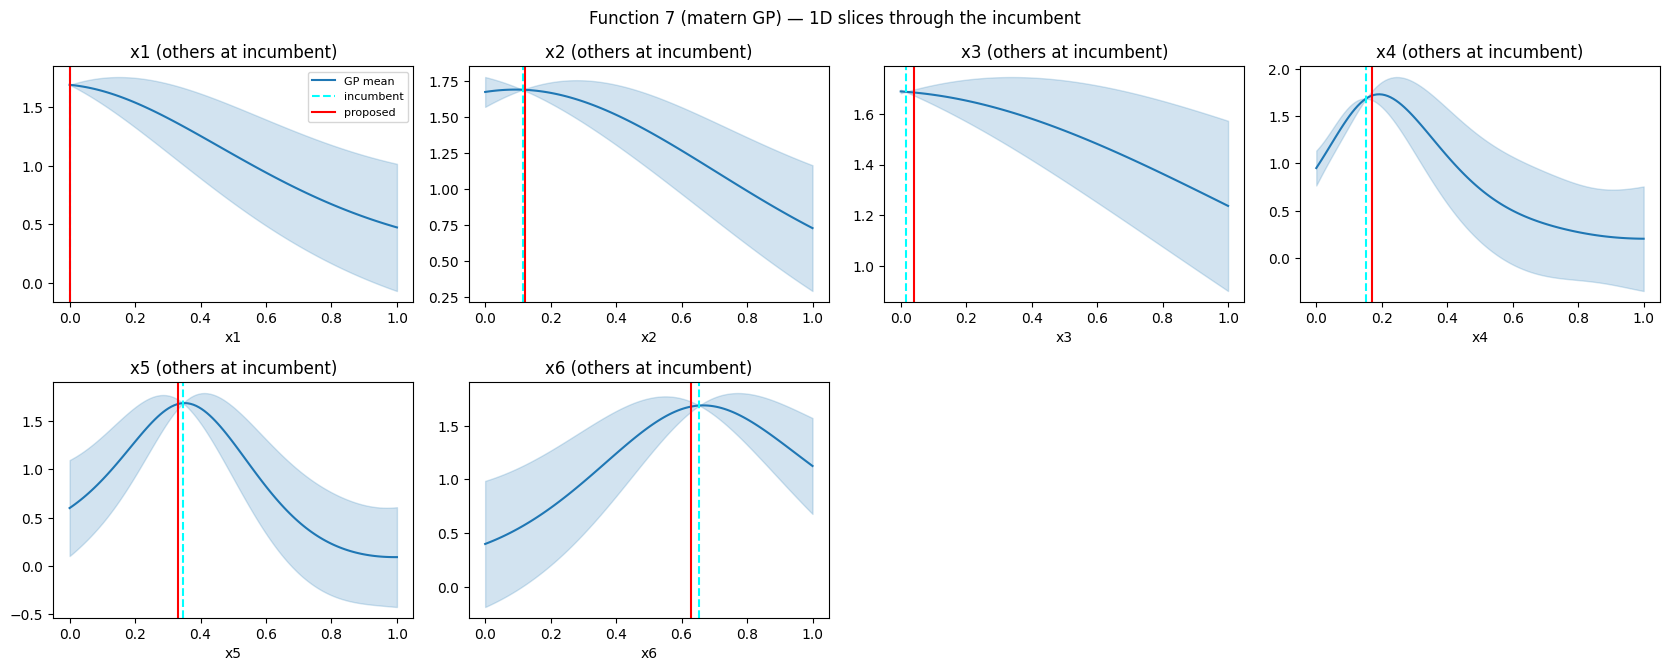

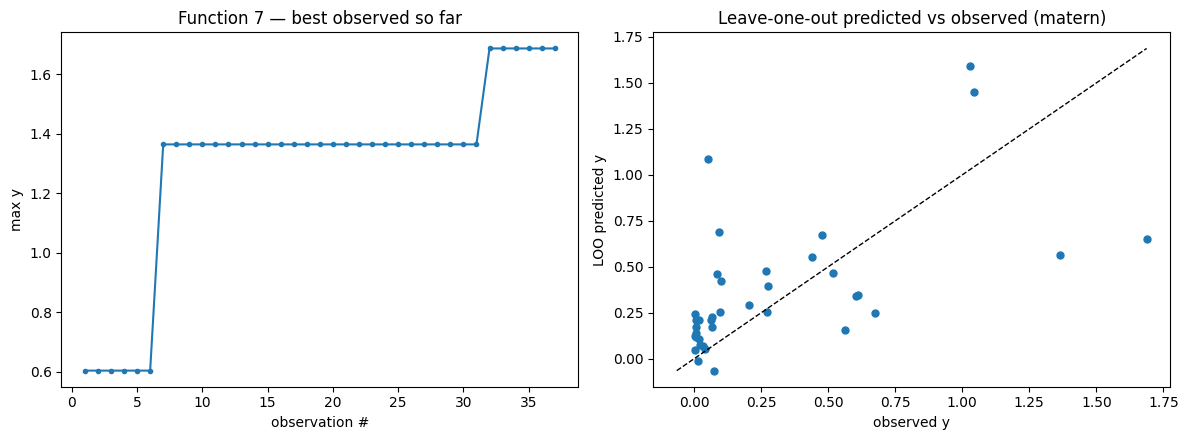

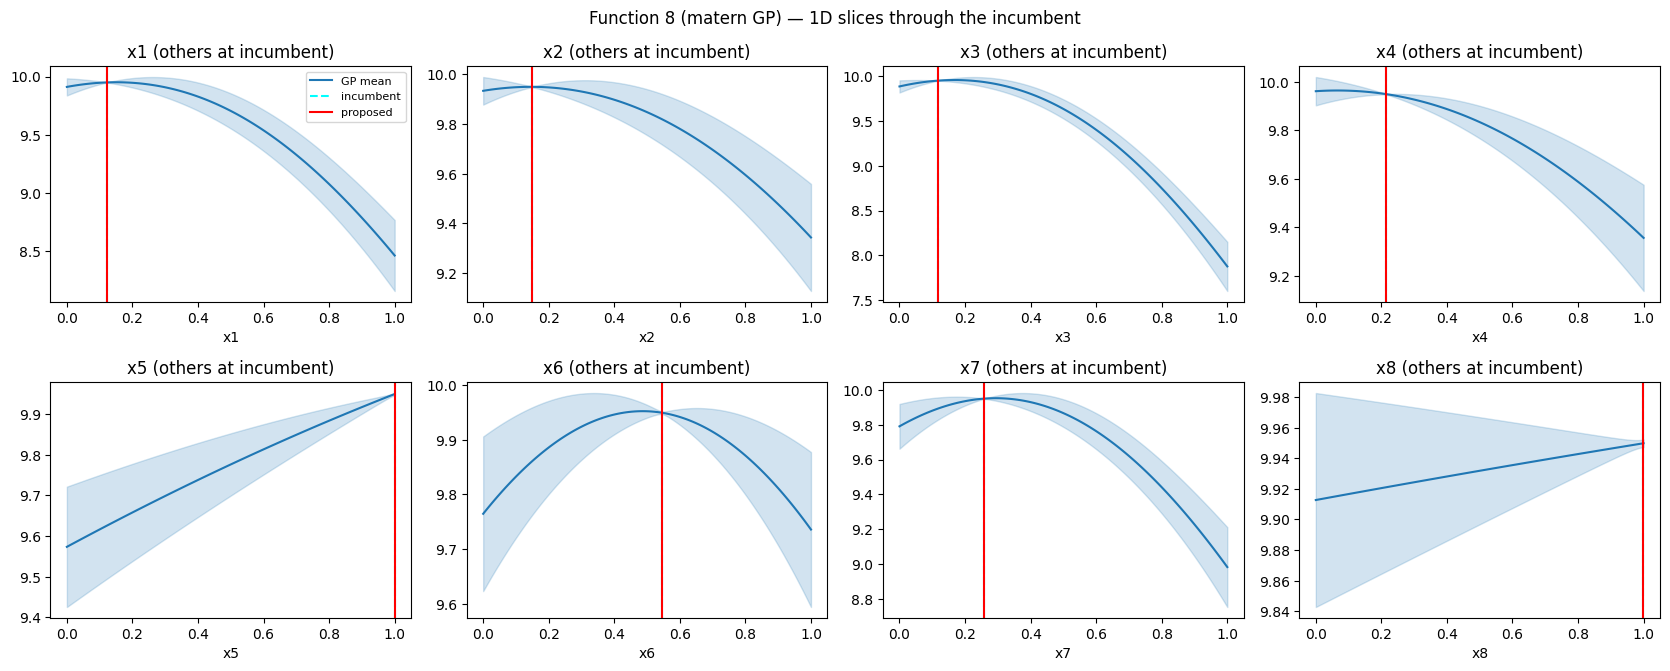

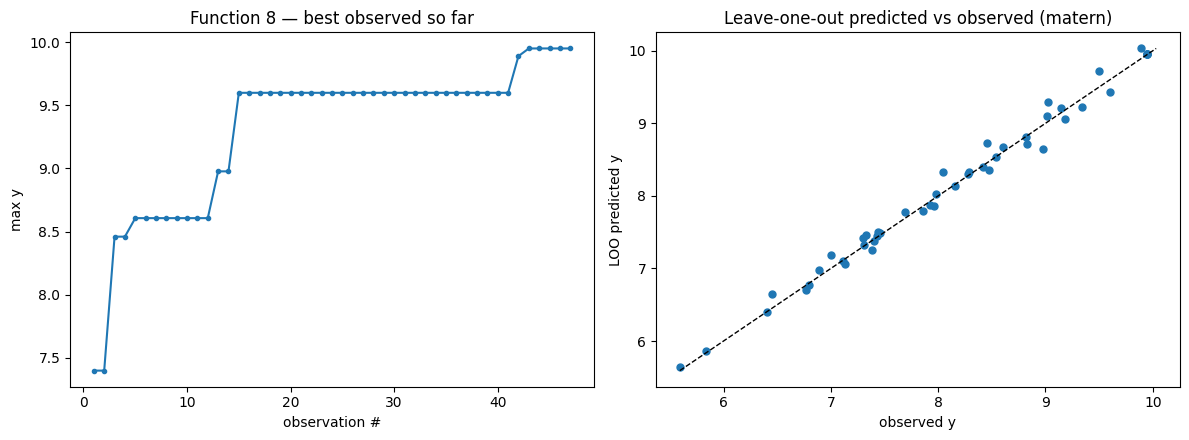

In [5]:
for fid in bo.FUNC_IDS:
    r = results[fid]; m = r.get("model") or bo.fit(fid)
    if m.d == 2:
        bo.plot_2d(m, proposed=r["x"], save=f"{OUTDIR}/f{fid}_2d.png")
    else:
        bo.plot_slices(m, proposed_u=r["u"], save=f"{OUTDIR}/f{fid}_slices.png")
    bo.plot_diagnostics(m, save=f"{OUTDIR}/f{fid}_diag.png")
    plt.show()


## 4. Submission strings - copy one per function into the portal

In [6]:
for fid in bo.FUNC_IDS:
    print(f"f{fid}:  {results[fid]['submission']}")

f1:  0.460000-0.490000
f2:  0.683947-0.025798
f3:  0.913105-0.000000-0.091277
f4:  0.411885-0.414684-0.365642-0.437550
f5:  0.965208-0.077388-0.960107-0.001138
f6:  0.479081-0.366380-0.597993-0.728146-0.000000
f7:  0.000000-0.121321-0.041032-0.171272-0.332222-0.628714
f8:  0.121737-0.148860-0.117769-0.213503-0.999999-0.545197-0.258398-0.997667


## 5. Write the weekly reflection scaffold
Creates `weekly/reflections/weekNN.md` if it doesn't exist yet. It will **not** overwrite a
reflection you've already written (pass `overwrite=True` to force a fresh scaffold).

In [7]:
path = bo.render_reflection(WEEK, results)   # won't overwrite an already-written reflection
print("reflection ->", path)


reflection -> /Users/jp/PycharmProjects/MachineLearning/Capstone/weekly/reflections/week08.md


## 6. After the portal returns each y - record results for next round
Fill in the returned outputs below, run the cell, then bump `WEEK` and re-run the notebook
next module. `append_result` grows each function's CSV by one row.

In [8]:
# Week 8 portal returns - already saved into data/fN.csv outside the notebook.
# returned_y = {
#     1: -0.000001359124064035148,
#     2: 0.49097448906384134,
#     3: -0.10477288668691394,
#     4: 0.5132161249540599,
#     5: 1079.2440799553353,
#     6: -0.25449286340676835,
#     7: 1.8389776860757907,
#     8: 9.9498951570636,
# }
#
# BEST ROUND SINCE W2 - THREE NEW BESTS:
#   f6 -0.254 vs -0.705  NEW BEST (+0.45) - conservative AEI delivered
#   f7  1.839 vs  1.688  NEW BEST (+0.15) - tight refine predicted 1.698, actual beat it
#   f8  9.94990 vs 9.94981  NEW BEST (marginal) - MES nudges the converged point up again
#
# The rest:
#   f1 -1.4e-06 at (0.46, 0.49): magnitude ~4000x SMALLER than W7's -0.0053 at (0.41, 0.47).
#      Signal fades toward centre -> the structure sits at/beyond (0.41, 0.47), away from centre.
#      Next probe: step the OTHER way, e.g. (0.36, 0.44).
#   f2 0.491 vs 0.611 (best miss in weeks; AEI is at least in the right area now)
#   f3 -0.105 vs -0.035 (EI miss)
#   f4 0.513 vs 0.540 (tight refine: close, no cigar - the peak is NARROW; ±0.02 cost 0.03)
#   f5 1079 (about the original seed-best level; another region mapped, corner still king)
#
# Strategy lesson: the conservative/banking moves (tight_refine, AEI-near-incumbent, MES)
# produced all three wins. Bold moves have now failed 4 weeks running. With ~2 rounds left,
# conservative refinement + final-week locks is the plan.
# for fid, y in returned_y.items():
#     bo.append_result(fid, results[fid]["x"], y)
# print("saved; dataset sizes now:", {fid: len(bo.load(fid)[1]) for fid in bo.FUNC_IDS})
